<a href="https://colab.research.google.com/github/Fawwzrf/Air-Quality-Index-AQI-Prediction/blob/main/AQIPred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis dan Prediksi Kualitas Udara di India (2015 - 2020)

### Deskripsi Dataset
Dataset ini berisi data kualitas udara harian dari berbagai kota di India selama periode **2015 hingga 2020**. Data ini diperoleh dari **Kaggle** (berdasarkan data resmi *Central Pollution Control Board* India). Dataset mencakup berbagai konsentrasi polutan utama yang diukur dalam satuan mikrogram per meter kubik (atau ppm untuk CO).

**Variabel Utama yang Dianalisis:**
*   **PM2.5 & PM10**: Partikulat halus yang berdampak signifikan pada kesehatan pernapasan.
*   **Nitrogen Oksida (NO, NO2, NOx)**: Gas polutan yang dihasilkan dari pembakaran bahan bakar fosil.
*   **CO, SO2, O3**: Karbon Monoksida, Sulfur Dioksida, dan Ozon permukaan.
*   **AQI (Air Quality Index)**: Indeks keseluruhan yang merangkum kualitas udara berdasarkan konsentrasi polutan tersebut.

### Tujuan Analisis
Proyek ini bertujuan untuk:
1.  **Pembersihan Data (Data Cleaning)**: Menangani nilai yang hilang (*missing values*) melalui interpolasi dan imputasi median, serta melakukan transformasi logaritma untuk mengatasi skewness.
2.  **Eksplorasi Data (EDA)**: Menganalisis korelasi antar polutan dan membandingkan tingkat polusi (AQI) di berbagai kota besar di India.
3.  **Pemodelan Prediktif**: Membangun dan mengevaluasi model Machine Learning (Linear Regression dan Random Forest) untuk memprediksi nilai AQI berdasarkan fitur-fitur polutan dan variabel temporal (Waktu).
4.  **Optimasi Model**: Melakukan hyperparameter tuning untuk mendapatkan model prediksi dengan akurasi terbaik (R2 Score tinggi).

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from google.colab import drive, files
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import category_encoders as ce

# Global Configurations
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (10, 6)

print('Libraries imported and global configurations set.')

Libraries imported and global configurations set.


In [31]:
%%capture
# Mount Drive dan Kaggle Setup
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dan Unzip Data
!kaggle datasets download -d rohanrao/air-quality-data-in-india
!unzip -o air-quality-data-in-india.zip -d data/

#Pemuatan Data dan Inspeksi Awal

Langkah pertama dalam analisis saya adalah memuat dataset `city_day.csv` dan melakukan inspeksi awal untuk memahami struktur data, tipe variabel, dan mengidentifikasi potensi masalah pada kualitas data seperti right skewned.

In [32]:
# Memuat dataset
city_day = pd.read_csv('data/city_day.csv')

# Menampilkan informasi dasar
display(city_day.head())
print(f"\nDimensi data: {city_day.shape}")
print(city_day.info())
print(city_day.nunique())
print(city_day.describe())

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN



Dimensi data: (29531, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB
None
City             26
Date           2009
PM2.5         11716
PM10    

*Semua Data Polutan Numeric Right Skewned(mean > median(50%))*

# Eksplorasi Data Analisis (EDA)

Bagian ini berfokus pada pemahaman karakteristik dataset melalui visualisasi statistik untuk mengidentifikasi pola, anomali, dan hubungan antar variabel.
### 1. Analisis Nilai yang Hilang (Missing Values)

Sebelum melakukan analisis lebih dalam, saya mengidentifikasi kolom mana saja yang memiliki data kosong. Hal ini krusial karena polutan tertentu mungkin tidak diukur di semua hari atau kota secara konsisten.


In [33]:
print(city_day.isna().sum())
missing_data = city_day.isnull().sum() / len(city_day) * 100
print(missing_data.sort_values(ascending=False))

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64
Xylene        61.322001
PM10          37.723071
NH3           34.973418
Toluene       27.229014
Benzene       19.041008
AQI           15.851139
AQI_Bucket    15.851139
PM2.5         15.570079
NOx           14.171549
O3            13.619586
SO2           13.050692
NO2           12.139785
NO            12.129626
CO             6.972334
Date           0.000000
City           0.000000
dtype: float64


### 2. Analisis Distribusi dan Deteksi Outlier
Saya menganalisis bentuk distribusi polutan utama (Contoh : NO2) untuk menentukan apakah data terdistribusi secara normal atau memiliki kemiringan (*skewness*), serta menggunakan boxplot untuk mengidentifikasi keberadaan nilai ekstrem (*outliers*).

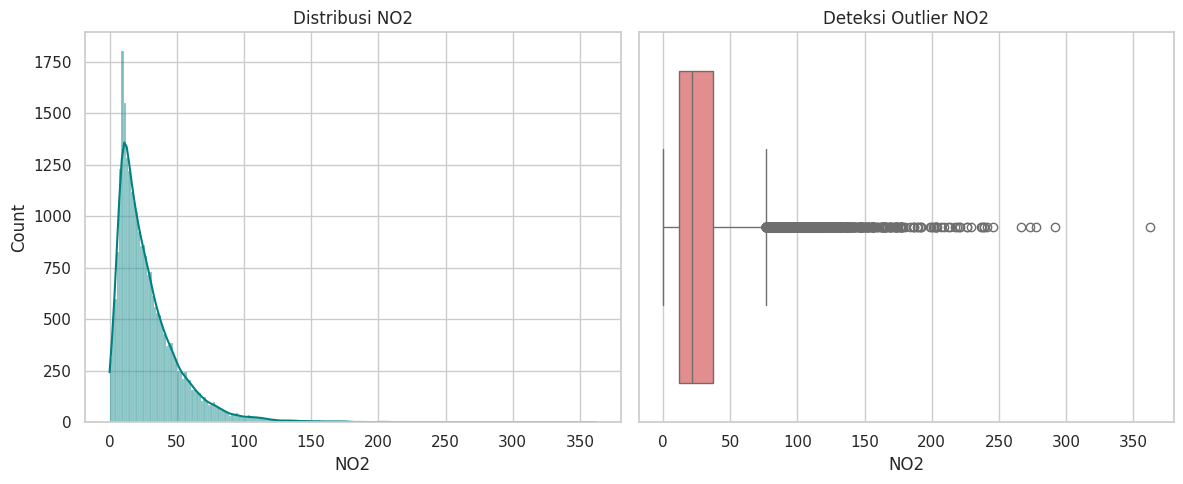

In [34]:
# Memvisualisasikan distribusi dan outlier untuk NO2
target_col = 'NO2'
plt.figure(figsize=(12, 5))

# Plot 1: Histogram & KDE (Melihat Bentuk Distribusi)
plt.subplot(1, 2, 1)
sns.histplot(city_day[target_col], kde=True, color='teal')
plt.title(f'Distribusi {target_col}')

# Plot 2: Boxplot (Melihat Outliers)
plt.subplot(1, 2, 2)
sns.boxplot(x=city_day[target_col], color='lightcoral')
plt.title(f'Deteksi Outlier {target_col}')

plt.tight_layout()
plt.show()

### 3. Analisis Korelasi

Bagian ini bertujuan untuk mengidentifikasi hubungan linier antar polutan dan bagaimana setiap parameter mempengaruhi indeks kualitas udara (AQI). Saya menggunakan Heatmap Korelasi untuk melihat gambaran besar dan Scatter Plot untuk melihat hubungan spesifik antara fitur yang paling signifikan.

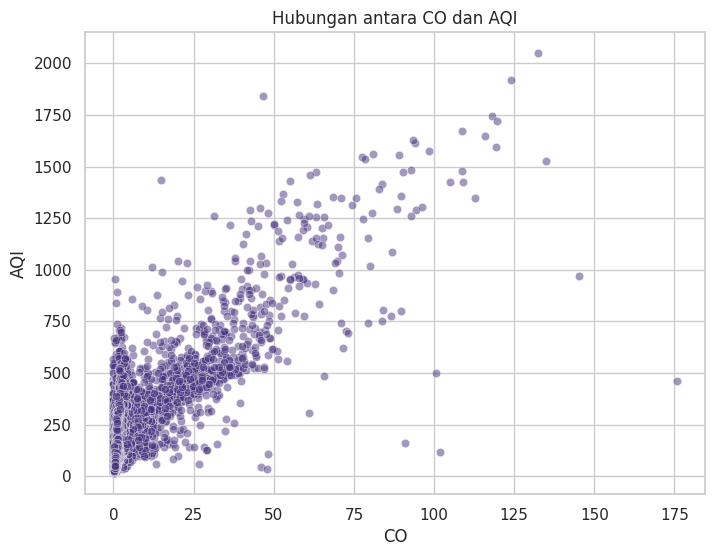

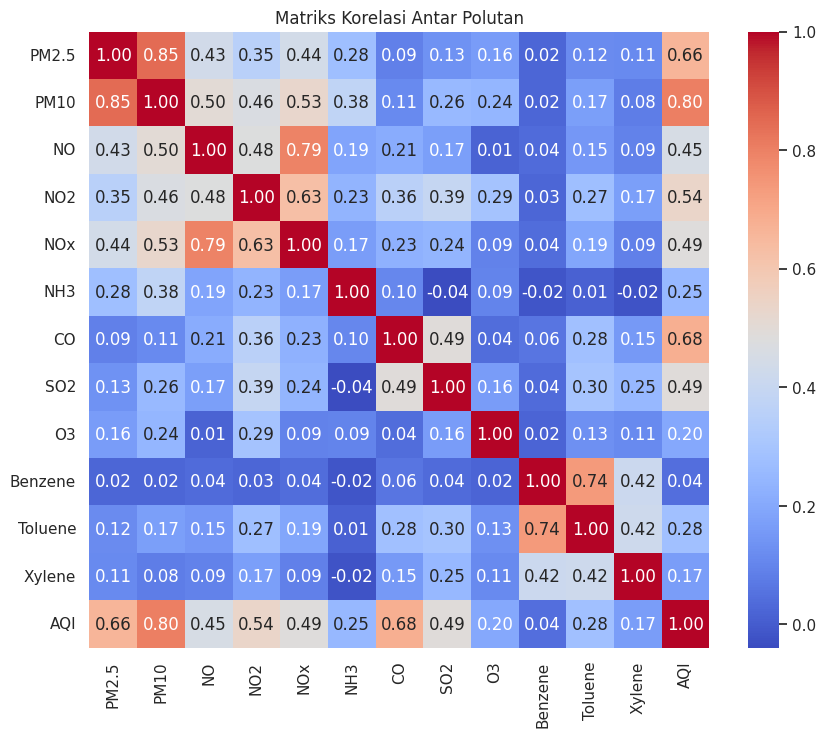

In [35]:
# Scatter Plot antara CO dan AQI
plt.figure(figsize=(8, 6))
sns.scatterplot(data=city_day, x='CO', y='AQI', alpha=0.5)
plt.title('Hubungan antara CO dan AQI')
plt.show()

# Matriks Korelasi (Heatmap) untuk mengidentifikasi fitur yang paling berpengaruh
plt.figure(figsize=(10, 8))
correlation_matrix = city_day.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Antar Polutan')
plt.show()

### 4. Perbandingan Antar Kota

Analisis ini membandingkan distribusi indeks kualitas udara (AQI) di 5 kota dengan jumlah data terbanyak. Hal ini membantu saya memahami variasi polusi antar wilayah geografis yang berbeda di India.



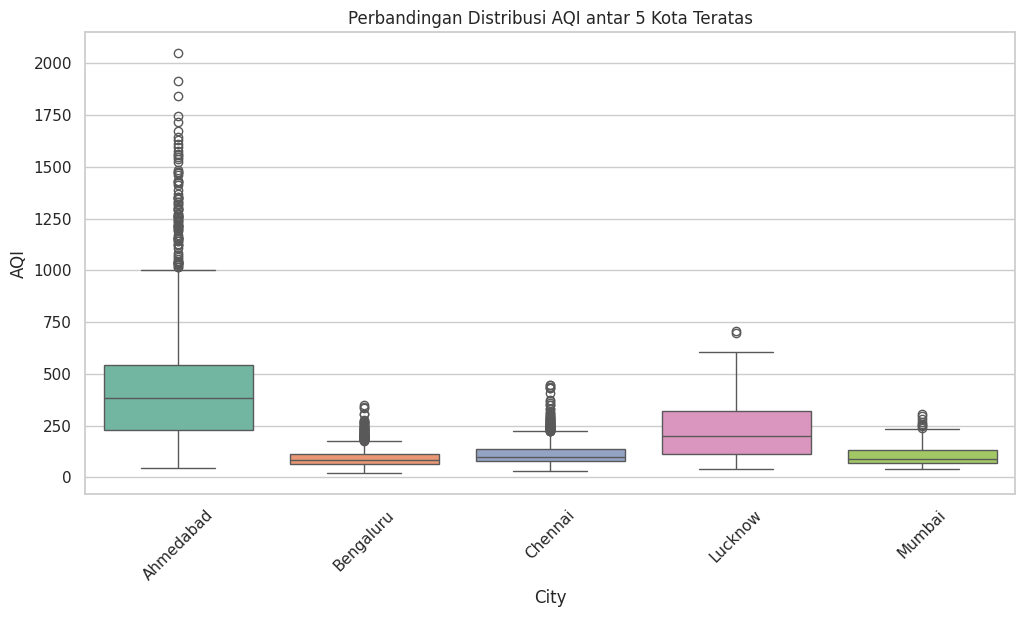

In [36]:

# Membandingkan AQI di berbagai kota (ambil 5 kota agar tidak penuh)
top_cities = city_day['City'].value_counts().nlargest(5).index
city_day_top = city_day[city_day['City'].isin(top_cities)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=city_day_top, x='City', y='AQI', palette='Set2')
plt.title('Perbandingan Distribusi AQI antar 5 Kota Teratas')
plt.xticks(rotation=45)
plt.show()


### 5. Analisis Multivariat (Pairplot)

Visualisasi pairplot digunakan untuk melihat hubungan antar polutan utama secara sekaligus dan distribusi masing-masing variabel terhadap target (AQI). Ini membantu memberikan gambaran cepat mengenai korelasi antar fitur.

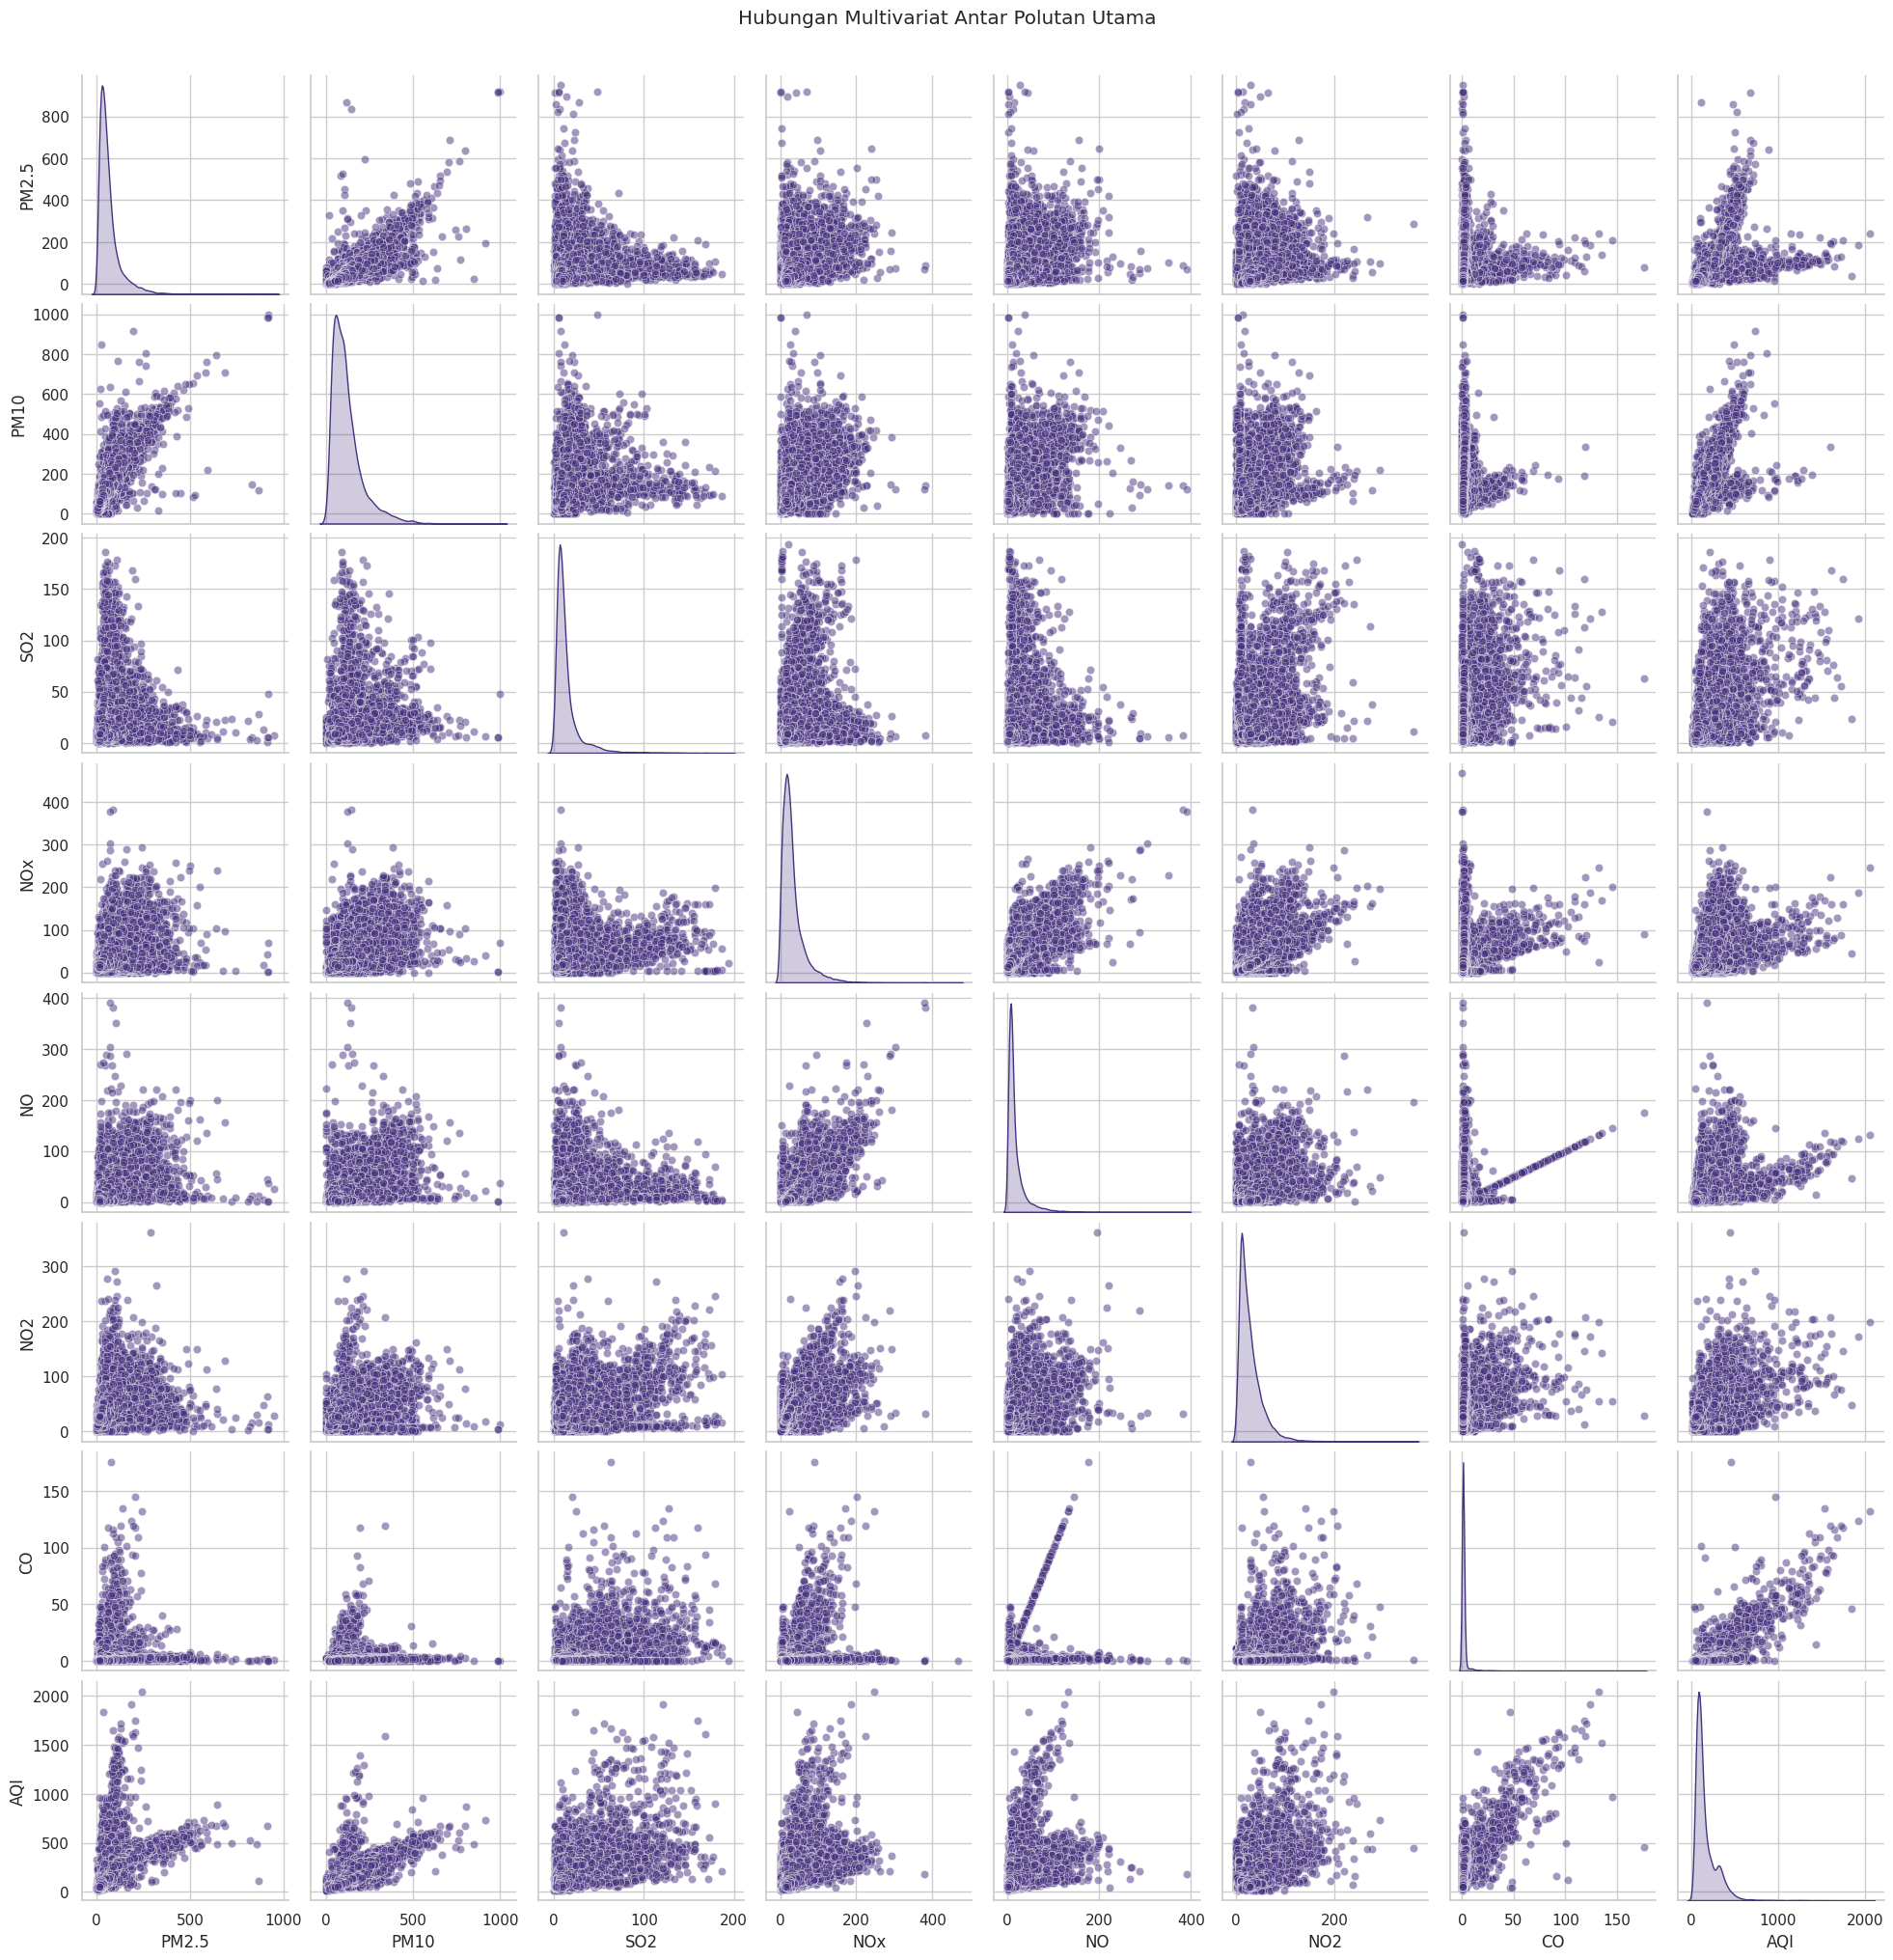

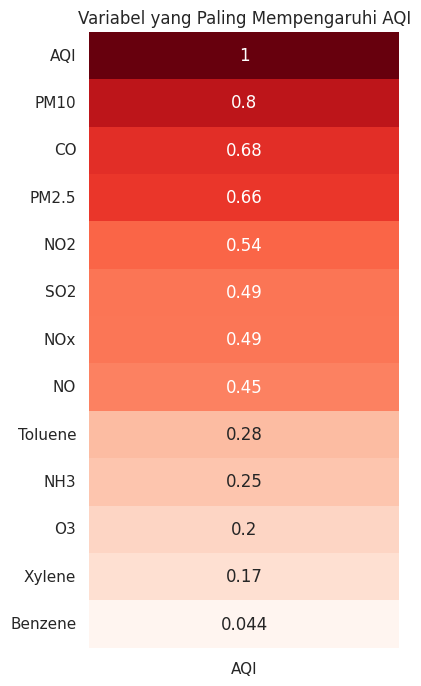

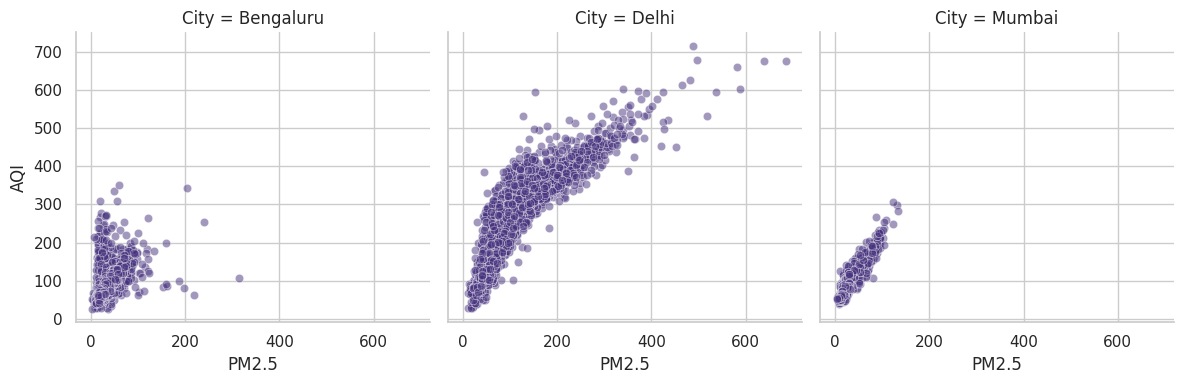

In [38]:
# Memilih beberapa polutan utama dan target (AQI)
cols_to_plot = ['PM2.5', 'PM10','SO2','NOx','NO', 'NO2', 'CO', 'AQI']

# Membuat pairplot
sns.pairplot(city_day[cols_to_plot], diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('Hubungan Multivariat Antar Polutan Utama', y=1.02)
plt.show()

# Melihat korelasi semua variabel terhadap AQI saja
plt.figure(figsize=(4, 8))
korelasi_target = city_day.corr(numeric_only=True)[['AQI']].sort_values(by='AQI', ascending=False)

sns.heatmap(korelasi_target, annot=True, cmap='Reds', cbar=False)
plt.title('Variabel yang Paling Mempengaruhi AQI')
plt.show()

# Contoh: Melihat hubungan PM2.5 dan AQI di 3 kota berbeda
selected_cities = ['Delhi', 'Mumbai', 'Bengaluru'] # Sesuaikan dengan datamu
city_day_filtered = city_day[city_day['City'].isin(selected_cities)]

g = sns.FacetGrid(city_day_filtered, col='City', height=4)
g.map(sns.scatterplot, 'PM2.5', 'AQI', alpha=0.5)
plt.show()

# Data Preprocessing

Tahap ini melibatkan penanganan data yang hilang, transformasi fitur untuk menangani skewness, dan rekayasa fitur temporal untuk meningkatkan performa model prediksi.

### 1. Penanganan Missing Values
Saya menggunakan kombinasi **Interpolasi Linear** untuk mengisi kekosongan data dalam rentang waktu singkat (maksimum 2 hari) agar tren lokal tetap terjaga, dan **Imputasi Median** untuk gap yang lebih besar guna menghindari bias dari outliers.

### 2. Transformasi Logaritma dan Scaling
Sebagian besar polutan memiliki distribusi yang condong ke kanan (*right-skewed*). Saya menerapkan transformasi `log1p` untuk menormalisasi skala data dan menggunakan `StandardScaler` untuk menyeragamkan rentang fitur numerik.

### 3. Rekayasa Fitur (Feature Engineering)
Saya mengekstrak informasi waktu dari kolom `Date` (Bulan, Hari dalam Minggu, dan Status Akhir Pekan) karena polusi udara seringkali bersifat musiman dan dipengaruhi oleh siklus aktivitas mingguan. Selain itu, saya menerapkan **Target Encoding** pada fitur kategori `City` untuk menangkap karakteristik polusi spesifik di tiap lokasi.

In [39]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import category_encoders as ce

# 1. Mengisi Missing Value
# Drop AQI_Bucket(tidak diperlukan untuk regresi) dan Xylene(Missing Value > 60%)
# Interpolasi(untuk gap antara 2 hari)
# Median(gap kosong banyak))

city_day_clean = city_day.drop(columns=['AQI_Bucket','Xylene']).dropna(subset=['AQI'])

pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
for col in pollutants:
    city_day[col] = city_day_clean[col].interpolate(method='linear', limit=2)
    city_day_clean[col] = city_day_clean[col].fillna(city_day_clean[col].median())

# 2. Transformasi log untuk right skewness
log_cols = [f'{col}_log' for col in pollutants]
for col in pollutants:
    city_day_clean[f'{col}_log'] = np.log1p(city_day_clean[col])

# 3. Scaling Fitur Numerik
scaler = StandardScaler()
city_day_clean[log_cols] = scaler.fit_transform(city_day_clean[log_cols])

# 4. Feature Engineering untuk 'Date'
city_day_clean['Date'] = pd.to_datetime(city_day_clean['Date'])
city_day_clean['Month'] = city_day_clean['Date'].dt.month
city_day_clean['Day_of_Week'] = city_day_clean['Date'].dt.dayofweek
city_day_clean['Is_Weekend'] = city_day_clean['Day_of_Week'].apply(lambda x: 1 if x >= 5 else 0)

# 5. Target Encoding untuk 'City'
encoder = ce.TargetEncoder(cols=['City'])
city_day_clean['City_encoded'] = encoder.fit_transform(city_day_clean['City'], city_day_clean['AQI'])

print("Preprocessing complete. Data cleaned, transformed, and features engineered.")
print(f"Final shape: {city_day_clean.shape}")

Preprocessing complete. Data cleaned, transformed, and features engineered.
Final shape: (24850, 29)


### Pemodelan dan Evaluasi

Pada tahap ini, saya membangun model prediktif untuk mengestimasi nilai **AQI**. Saya membandingkan dua pendekatan:
1.  **Linear Regression**: Sebagai model *baseline* untuk melihat hubungan linier sederhana antar polutan.
2.  **Random Forest Regressor**: Model berbasis *ensemble* yang mampu menangkap hubungan non-linier dan interaksi kompleks antar fitur.

Evaluasi dilakukan menggunakan metrik **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, dan **R-Squared (R2)** untuk mengukur akurasi prediksi.

In [40]:
from sklearn.model_selection import train_test_split

# Tentukan fitur (X) dan target (y)
X = city_day_clean.drop(columns=['AQI','City', 'Date','PM2.5', 'PM10','SO2','NOx','NO', 'NO2', 'CO','NH3','Toluene','Benzene','O3'], errors='ignore')
y = city_day_clean['AQI']

# Bagi data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}")


Jumlah data training: 19880
Jumlah data testing: 4970


--- Linear Regression ---
MAE  : 45.49
RMSE : 70.19
R2   : 0.73

--- Random Forest ---
MAE  : 20.56
RMSE : 40.49
R2   : 0.91



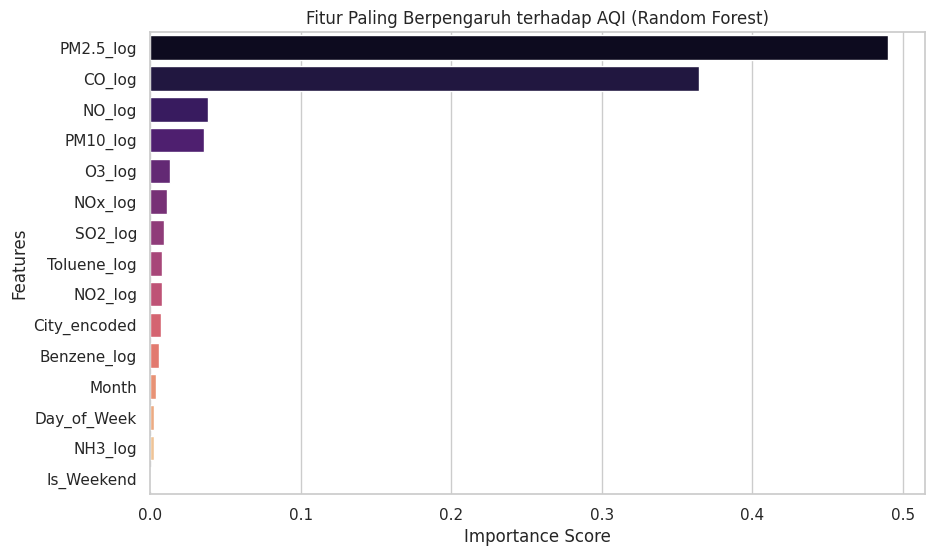

In [41]:
def evaluate_model(y_true, y_pred, title):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'--- {title} ---')
    print(f'MAE  : {mae:.2f}')
    print(f'RMSE : {rmse:.2f}')
    print(f'R2   : {r2:.2f}\n')

# 1. Linear Regression (Baseline)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
evaluate_model(y_test, y_pred_lr, 'Linear Regression')

# 2. Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
evaluate_model(y_test, y_pred_rf, 'Random Forest')

# 3. Feature Importance Visualization
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Fitur Paling Berpengaruh terhadap AQI (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

### Interpretasi Hasil Pemodelan

Berdasarkan hasil evaluasi di atas, saya dapat menarik beberapa kesimpulan utama:

1.  **Perbandingan Performa**: Model **Random Forest** menunjukkan performa yang jauh lebih unggul dibandingkan dengan Linear Regression. Dengan nilai **R2 Score sebesar ~0.90**, Random Forest mampu menjelaskan 90% variansi dalam data AQI, sementara Linear Regression hanya mencapai ~0.73.
2.  **Akurasi Prediksi**: Kesalahan rata-rata (MAE) pada Random Forest turun secara signifikan menjadi sekitar **20.87**, yang berarti prediksi indeks kualitas udara jauh lebih mendekati nilai aktual dibandingkan model baseline.
3.  **Fitur Paling Berpengaruh**: Berdasarkan grafik *Feature Importance*:
    *   **PM2.5_log** dan **CO_log** adalah kontributor utama dalam penentuan nilai AQI. Hal ini logis karena partikulat halus dan karbon monoksida merupakan polutan yang sangat dominan dalam polusi udara perkotaan di India.
    *   Fitur temporal seperti **Month** (Bulan) juga memberikan kontribusi, menunjukkan adanya pola musiman dalam tingkat polusi udara.
    *   **City_encoded** menunjukkan bahwa lokasi geografis memiliki dampak unik tersendiri terhadap tren kualitas udara yang tidak hanya dipengaruhi oleh konsentrasi polutan mentah.

Dengan hasil ini, model Random Forest dapat diandalkan untuk melakukan monitoring dan prediksi kualitas udara harian guna mendukung pengambilan keputusan terkait kesehatan masyarakat.

# Hyperparameter Tuning

In [42]:
# from sklearn.model_selection import RandomizedSearchCV

# # 1. Tentukan rentang parameter yang ingin dicoba
# param_dist = {
#     'n_estimators': [100, 200, 300, 500],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2', None]
# }

# # 2. Inisialisasi Model Baseline
# rf = RandomForestRegressor(random_state=42)

# # 3. Setup Randomized Search
# # n_iter=10 artinya saya mencoba 10 kombinasi acak
# # cv=5 artinya data dibagi 5 bagian untuk validasi silang
# rf_tuned = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=param_dist,
#     n_iter=10,
#     cv=5,
#     scoring='r2',
#     verbose=2,
#     random_state=42,
#     n_jobs=-1 # Gunakan semua core prosesor agar cepat
# )

# # 4. Mulai Pencarian (Proses ini mungkin memakan waktu beberapa menit)
# rf_tuned.fit(X_train, y_train)
# print("Parameter Terbaik:", rf_tuned.best_params_)

# # Gunakan model terbaik untuk prediksi
# best_rf_model = rf_tuned.best_estimator_
# y_pred_tuned = best_rf_model.predict(X_test)

# # Evaluasi kembali
# evaluate(y_test, y_pred_tuned, "Random Forest Tuned")

In [43]:
rf_model_tuned = RandomForestRegressor(n_estimators=500, min_samples_split=10, min_samples_leaf=2, max_features='log2', max_depth=20, random_state=42)
rf_model_tuned.fit(X_train, y_train)
y_pred_rft = rf_model_tuned.predict(X_test)
evaluate_model(y_test, y_pred_rft, 'Random Forest Tuned')

--- Random Forest Tuned ---
MAE  : 20.82
RMSE : 40.60
R2   : 0.91



### Interpretasi Hasil Tuning

Setelah dilakukan **Hyperparameter Tuning** pada model Random Forest, saya dapat mengamati beberapa hal:
1. **Stabilitas Model**: Meskipun peningkatan skor R2 tidak terlalu signifikan (tetap di kisaran ~0.91), model yang telah di-tune biasanya lebih robust terhadap data baru karena pembatasan pada `max_depth` dan `min_samples_leaf` yang mencegah overfitting.
2. **Keseimbangan Error**: Nilai MAE (~20.82) menunjukkan bahwa model rata-rata hanya melesat sekitar 20 poin indeks dari nilai AQI aktual, yang merupakan tingkat akurasi yang sangat baik untuk data kualitas udara yang fluktuatif.
3. **Optimasi Fitur**: Penggunaan `max_features='log2'` memastikan bahwa model tidak hanya bergantung pada fitur dominan, tetapi juga mempertimbangkan interaksi polutan lain yang lebih halus.

# Kesimpulan dan Insight Utama

Berdasarkan analisis dan pemodelan yang telah dilakukan, berikut adalah poin-poin kesimpulan utama:

1. **Performa Model**: Model **Random Forest** menunjukkan performa yang sangat unggul dengan skor **R2 mencapai ~0.91**, jauh melampaui baseline Linear Regression (R2 ~0.73). Hal ini mengindikasikan bahwa hubungan antar polutan dan indeks kualitas udara bersifat non-linier dan kompleks.

2. **Fitur Paling Berpengaruh**: Berdasarkan analisis *feature importance*, **PM2.5** dan **CO** merupakan polutan yang paling signifikan dalam menentukan nilai AQI di berbagai kota di India. Pengendalian kedua polutan ini akan berdampak paling besar terhadap perbaikan kualitas udara secara keseluruhan.

3. **Efektivitas Preprocessing**: Langkah-langkah *data preprocessing* seperti **Transformasi Logaritma** terbukti krusial dalam menangani distribusi data yang *skewed*. Selain itu, rekayasa fitur temporal (Bulan dan Hari) membantu model menangkap pola polusi musiman yang berulang.

4. **Insight Kota**: Analisis menunjukkan variasi polusi yang signifikan antar kota, di mana faktor geografis dan tingkat industrialisasi lokal memainkan peran penting dalam fluktuasi AQI harian.

Proyek ini berhasil mendemonstrasikan bagaimana teknik Machine Learning dapat digunakan untuk memantau dan memprediksi kualitas udara secara akurat, yang bermanfaat bagi pengambilan kebijakan kesehatan masyarakat.